#IMPORT LIBRARY

# Heart Attack Risk Analysis

## Problem Statement
Memprediksi risiko serangan jantung pasien menggunakan data klinis dan gaya hidup,
dengan tujuan mengidentifikasi faktor faktor yang paling berasosiasi dengan risiko tinggi.

## Dataset
7000 data pasien, 21 fitur (klinis, demografis, gaya hidup), target biner heart_attack_risk.
Distribusi kelas 58% risiko rendah dan 42% risiko tinggi.

## Key EDA Findings
- Age dan max_heart_rate adalah dua prediktor numerik terkuat
- Smoking status, chest_pain_type, st_slope, dan thalassemia adalah prediktor kategorikal terkuat
- Gender, resting_ecg, dan alcohol consumption sinyalnya lemah

## Model Results
| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|-------|----------|-----------|--------|----|---------|
| Logistic Regression | 0.78 | 0.75 | 0.72 | 0.73 | 0.87 |
| Random Forest          | 0.76 | 0.74 | 0.65 | 0.69 | 0.84 |

## Conclusion
Logistic Regression dipilih sebagai model terbaik dengan ROC-AUC 0.871 dan Recall 0.720,
mengungguli Random Forest di semua metrik utama. Dalam konteks prediksi risiko medis,
Recall yang tinggi sangat penting untuk memastikan pasien berisiko tinggi tidak luput dari deteksi.

Secara keseluruhan, faktor klinis seperti age, max_heart_rate, chest_pain_type, dan st_slope
terbukti menjadi prediktor paling kuat, sementara beberapa faktor gaya hidup seperti gender
dan alcohol consumption menunjukkan sinyal yang lemah di dataset ini.

## Limitations
- Missing values diimputasi dengan median/mode, bukan data asli
- Belum dilakukan hyperparameter tuning
- Model belum divalidasi di luar dataset ini

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_style("whitegrid")
heart = pd.read_csv("heart_attack_dataset (1).csv")

In [2]:
heart.head(n=10)
heart.shape
heart.info()
heart.describe(include= "all").T

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           7000 non-null   int64  
 1   age                  7000 non-null   int64  
 2   gender               7000 non-null   str    
 3   chest_pain_type      7000 non-null   str    
 4   resting_bp           6720 non-null   float64
 5   cholesterol          6602 non-null   float64
 6   fasting_blood_sugar  6804 non-null   float64
 7   resting_ecg          6801 non-null   str    
 8   max_heart_rate       6721 non-null   float64
 9   exercise_angina      7000 non-null   int64  
 10  oldpeak              6650 non-null   float64
 11  st_slope             7000 non-null   str    
 12  num_major_vessels    7000 non-null   int64  
 13  thalassemia          7000 non-null   str    
 14  bmi                  6670 non-null   float64
 15  smoking_status       6495 non-null   str    
 16 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,7000.0,NaN,NaN,NaN,3500.5,2020.870275,1.0,1750.75,3500.5,5250.25,7000.0
age,7000.0,NaN,NaN,NaN,51.919857,13.891205,18.0,43.0,52.0,61.0,90.0
gender,7000,2,Male,3955,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chest_pain_type,7000,4,Non-anginal Pain,2147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
resting_bp,6720.0,NaN,NaN,NaN,116.447917,13.197267,80.0,107.0,116.0,125.0,162.0
cholesterol,6602.0,NaN,NaN,NaN,184.647683,33.180086,100.0,162.0,184.0,207.0,316.0
fasting_blood_sugar,6804.0,NaN,NaN,NaN,0.252939,0.434728,0.0,0.0,0.0,1.0,1.0
resting_ecg,6801,3,Normal,3763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max_heart_rate,6721.0,NaN,NaN,NaN,173.942717,15.125315,115.0,164.0,174.0,184.0,210.0
exercise_angina,7000.0,NaN,NaN,NaN,0.323714,0.467926,0.0,0.0,0.0,1.0,1.0


In [3]:
heart.isnull().sum().sort_values(ascending=False)
heart["heart_attack_risk"].value_counts(normalize=True)

heart_attack_risk
0    0.58
1    0.42
Name: proportion, dtype: float64

Cleaning Data

In [4]:
heart_clean = heart.copy()

#Numering columns with the missing values
#Missing values in numerical columns are filled with the median of the column

num_cols = ["resting_bp", 
            "cholesterol", 
            "fasting_blood_sugar", 
            "max_heart_rate", 
            "oldpeak",
            "bmi",
            "stress_level"]
for col in num_cols:
    heart_clean[col] = heart_clean[col].fillna(heart_clean[col].median())
    
#Categorical columns with the missing values
#Missing values in categorical columns are filled with the mode of the column

cat_cols = ["resting_ecg",
            "smoking_status",
            "alcohol_consumption",
            "physical_activity",]
for col in cat_cols:
    heart_clean[col] = heart_clean[col].fillna(heart_clean[col].mode()[0])
    
    heart_clean.isnull().sum().sum()

In [5]:
#Sanity check to ensure that there are no missing values in the dataset after the cleaning process

heart_clean[["age",
             "resting_bp", 
             "cholesterol", 
             "bmi"]]

,age,resting_bp,cholesterol,bmi
0,59,105.0,154.0,23.5
1,50,102.0,180.0,19.3
2,61,117.0,213.0,30.5
3,73,121.0,208.0,28.6
4,49,106.0,157.0,21.4
...,...,...,...,...
6995,48,108.0,127.0,30.0
6996,63,107.0,194.0,24.8
6997,45,98.0,119.0,18.7
6998,52,126.0,195.0,34.5


EXPLORATORY DATA ANALYSIS NUMERICAL FEATURES VS RISK


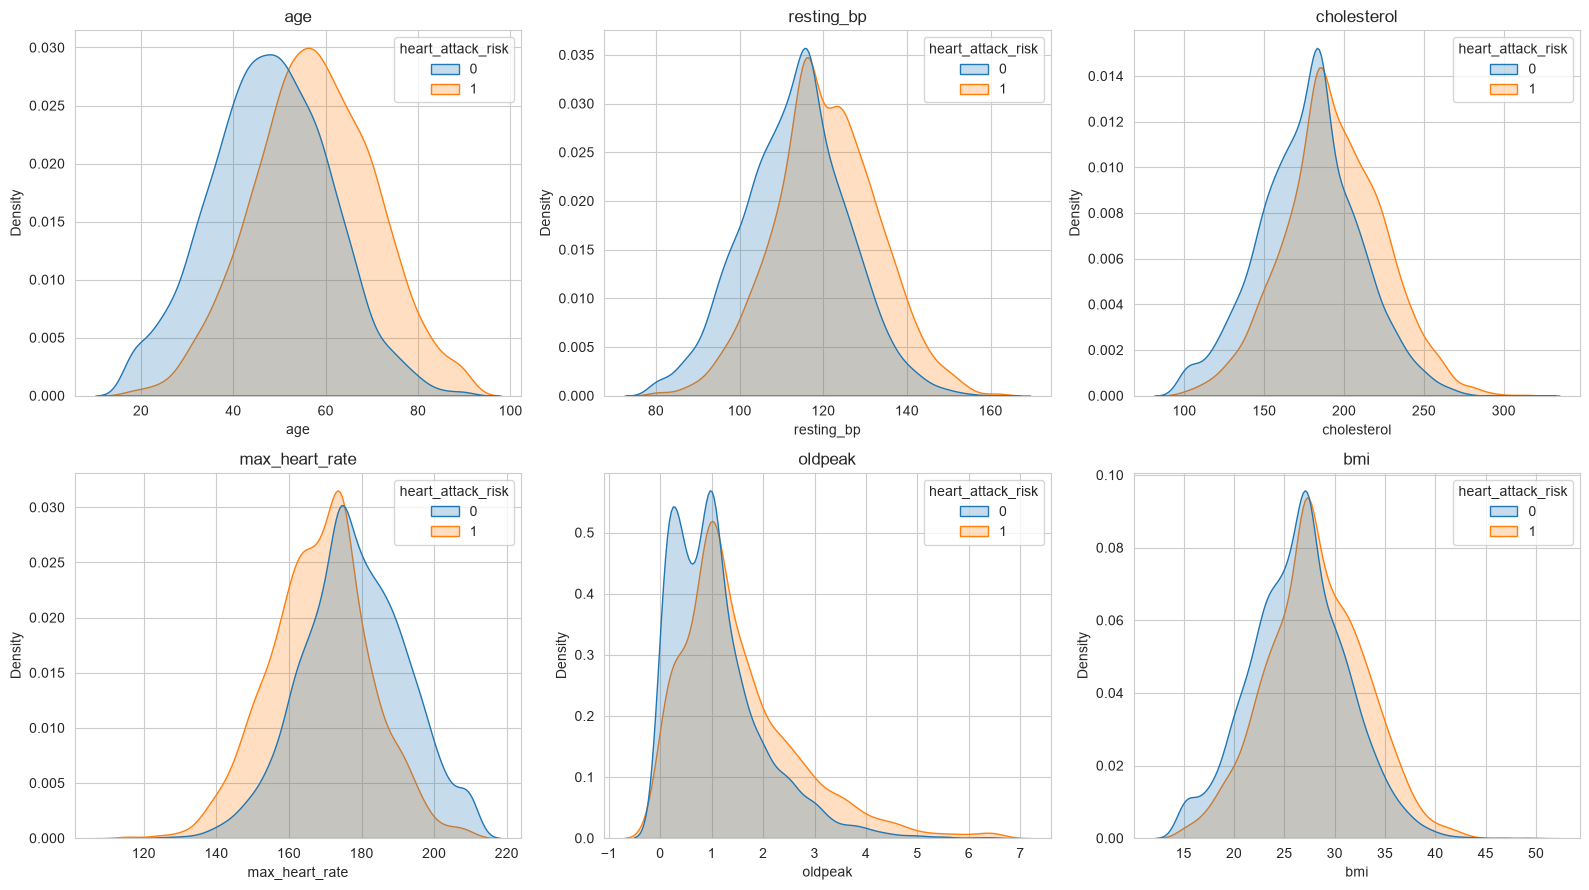

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
num_feats = ["age", "resting_bp", "cholesterol", "max_heart_rate", "oldpeak", "bmi"]
for ax, col in zip(axes.flat, num_feats):
    sns.kdeplot(data=heart_clean, x=col, hue="heart_attack_risk", ax=ax, fill=True, common_norm=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()

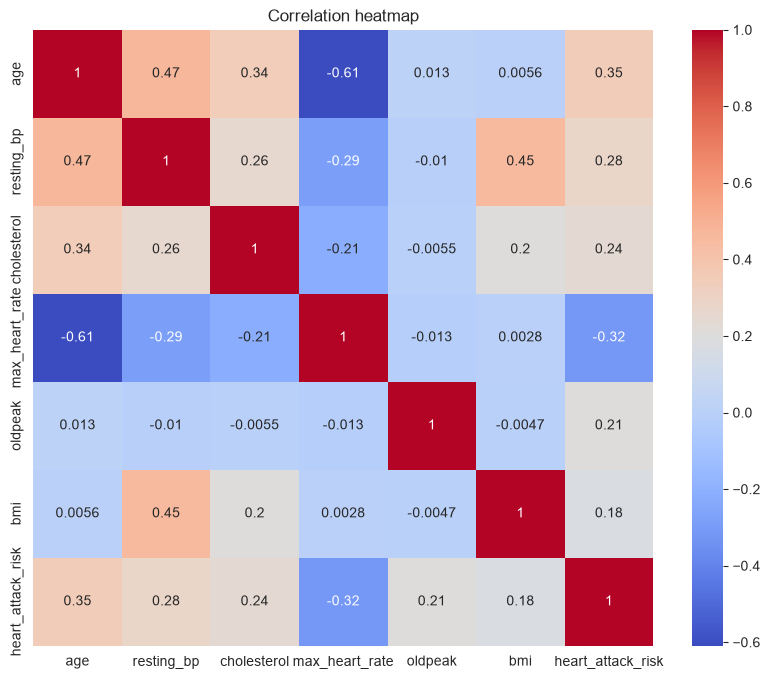

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(heart_clean[num_feats + ["heart_attack_risk"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation heatmap")
plt.show()

EXPLORATORY DATA ANALYSIS (EDA) CATEGORICAL FEATURES VS RISK

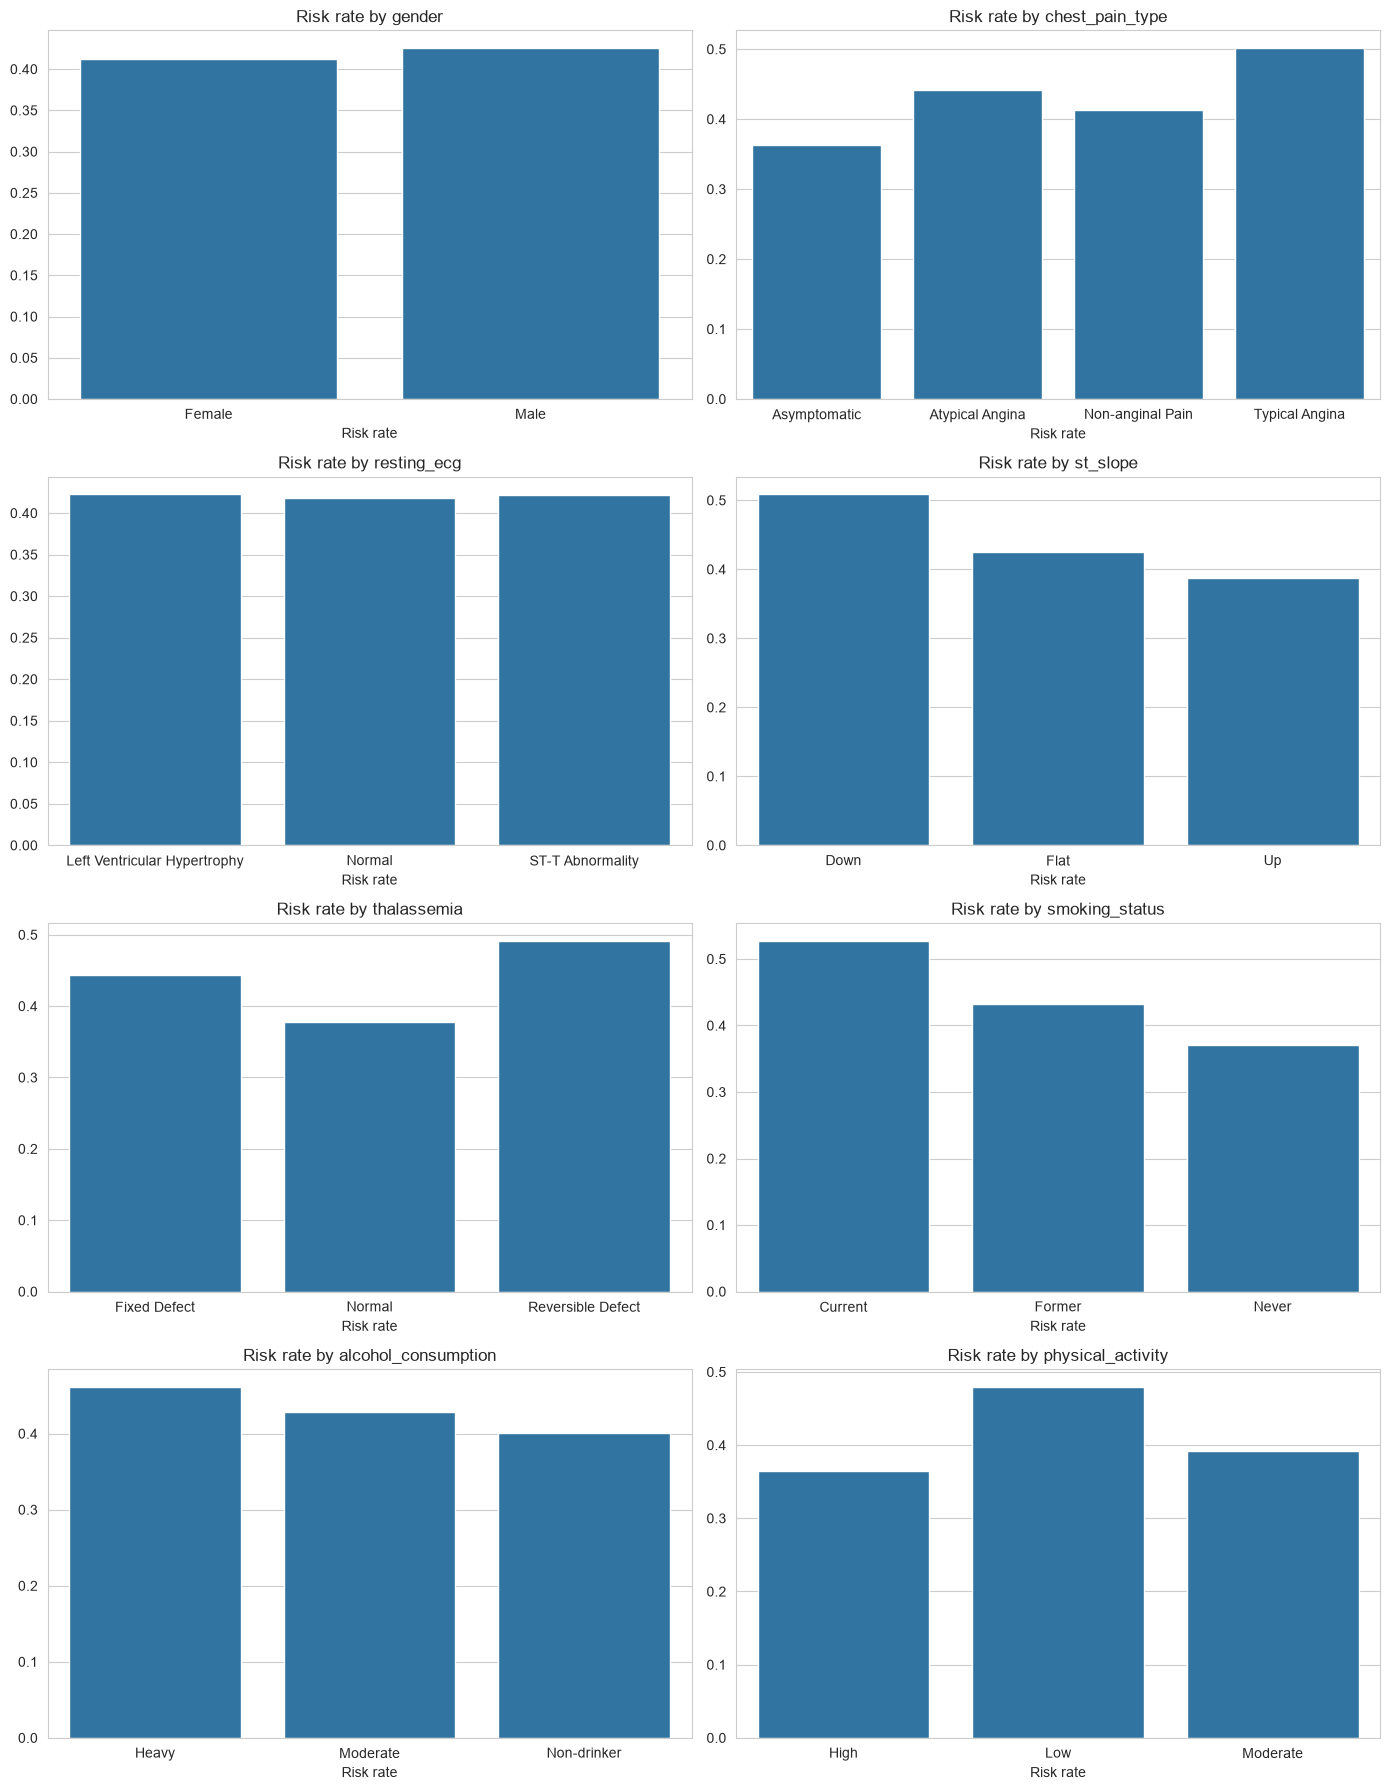

In [8]:
cat_feats = ["gender",
             "chest_pain_type",
             "resting_ecg",
             "st_slope",
             "thalassemia",
             "smoking_status",
             "alcohol_consumption",
             "physical_activity"]

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
for ax, col in zip (axes.flat, cat_feats):
    rate = heart_clean.groupby(col)["heart_attack_risk"].mean()
    sns.barplot(x=rate.index, y=rate.values, ax=ax)
    ax.set_title(f"Risk rate by {col}")
    ax.set_xlabel("Risk rate")
plt.tight_layout()
plt.show()
 

In [9]:
#binary flags

for col in ["exercise_angina",
            "family_history",
            "diabetes",]:
    print (heart_clean.groupby(col)["heart_attack_risk"].mean())
    print("\n")

exercise_angina
0    0.360161
1    0.545013
Name: heart_attack_risk, dtype: float64


family_history
0    0.375676
1    0.530114
Name: heart_attack_risk, dtype: float64


diabetes
0    0.365288
1    0.631250
Name: heart_attack_risk, dtype: float64




1. Age merupakan faktor numerik paling kuat pengaruhnya ke resiko. Distribusi orange (risk=1) jelas bergeser ke kanan dibanding ke biru, puncaknya disekitar usia 55 sampai 65 tahun, sementara grup tanpa resiko puncaknya di 45 hingga 50 tahun. Ini juga konsisten dengan heatmap korelasi, dimana Age punya korelasi 0.35 terhadapat heart_attack_risk.

2. Max Heart Rate punya hubungan terbalik dengan risiko, dan ini korelasi terkuat di seluruh dataset. Kelompok berisiko cenderung punya max_heart_rate yang rendah, dan di heatmap angkanya minus 0.32, ini magnitude korelasi terbesar terhadapt target, bahkan lebih kuat dari Age. Layaknya dijadikan temuan utama untuk variable numerik.

3. Resting BP dan Oldpeak sama sama mendorong risiko naik, tapi pengaruhnya lebih lemah. Resting_bp memnunjukan pergeseran ringan ke kanan untuk risk = 1 (korelasi=0.28), dan oldpeak punya ekor kanan yang lebih tebal di grup berisiko (korelasi = 0.21). Artinya orang dengan ST depression lebih tinggi cenderung sedikit lebih berisiko, walaupun mayoritas kedua grup masih banyak overlap.

4. Faktor Gaya Hidup dan kategoru risiko lain hasilnya tidak konsisten, ada yang sesuai ekspektasi klinis, ada yang tidak. Smoking ceritanya paling jelas, perokok aktif risikonya jauh diatas yang mantan dan tidak pernah merokok (sekitar 0.52 vs 0.43 vs 0.36). Tapi physical_activity malah terbalik, kategori "Low" justru resikonya paling tinggi (sekitar 0.48), sementara "High" paling rendah (sekitar 0.36). Yang aneh "Moderate" juga rendah (Sekitar 0.39) jadi polanya tidak membentuk gradien yang rapi. Alkohol consumption juga agak janggal, "Heavy" memiliki resiko paling tinggi sesuai ekspektasi tapi selisih antar kategori sangat kecil     (0.40 sampai 0.47) jadi ini lebih cocok disebut sinyal lemah daripada sinyal kuat

5. Fitur kategorikal klinis(chest_pain, st_slope, thalasemia) memisahkan risiko lebih baik dibanding fitur gaya hidup. Typical Angina (sekitar 0.50) dan Asymptomatic ( sekitar 0.36) jadi dua ujung yang berlawanan di chest pain. ST_slope "Down" (sekitar 0. 51) jauh lebih berisiko dibanding "Up"( sekitar 0.38). Thalasemia tipe reversible defect (Sekitar 0.49) juga menonjol. Fitur klinis kategorikal ini menunjukan pemisahan yang lebih jelas dibanding gender, resting_ecg, atau alcohol yang hampir flat di semua kategorinya.

PREPERATION FOR MODELING


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

model_df = heart_clean.drop(columns=["patient_id"])
model_df = pd.get_dummies(model_df, drop_first=True) #one-hot encoding for categorical variables

x = model_df.drop(columns=["heart_attack_risk"])
y = model_df["heart_attack_risk"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
num_cols_full = x_train.select_dtypes(include=np.number).columns
x_train[num_cols_full] = scaler.fit_transform(x_train[num_cols_full])
x_test[num_cols_full] = scaler.transform(x_test[num_cols_full])

BASELINE MODEL : LOGISTIC REGRESSION

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       815
           1       0.75      0.72      0.73       585

    accuracy                           0.78      1400
   macro avg       0.77      0.77      0.77      1400
weighted avg       0.78      0.78      0.78      1400

ROC AUC: 0.8711174033873421


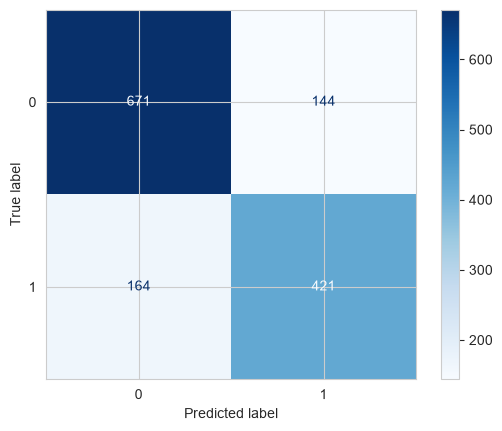

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

logreg =   LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)

y_pred = logreg.predict(x_test)
y_proba = logreg.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred))
print ("ROC AUC:", roc_auc_score(y_test, y_proba))
ConfusionMatrixDisplay.from_estimator(logreg, x_test, y_test, cmap="Blues")
plt.show()

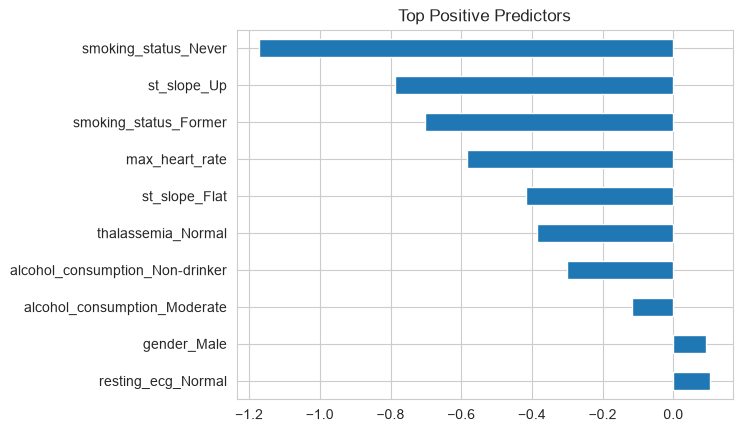

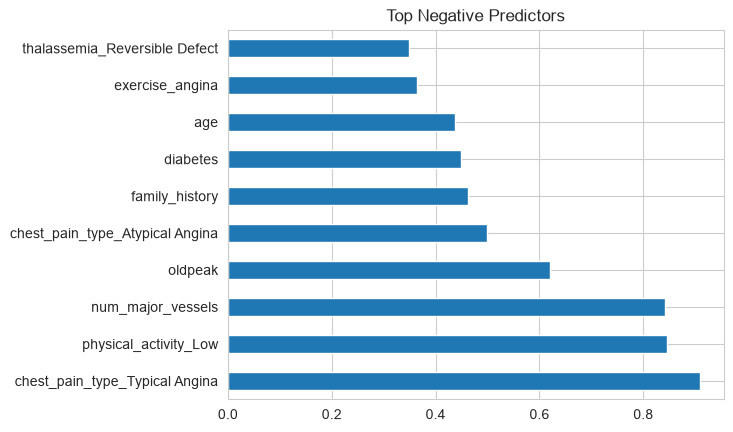

In [12]:
#feature importance (coefficients of the logistic regression model)

coef = pd.Series(logreg.coef_[0], index=x_train.columns).sort_values(ascending=False)

coef.tail(10).plot(kind="barh", title="Top Positive Predictors")
plt.show()

coef.head(10).plot(kind="barh", title="Top Negative Predictors")
plt.show()

SECOND MODEL : RANDOM FOREST(COMPARISON

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       815
           1       0.74      0.65      0.69       585

    accuracy                           0.76      1400
   macro avg       0.76      0.75      0.75      1400
weighted avg       0.76      0.76      0.76      1400

ROC AUC: 0.8465187981752398


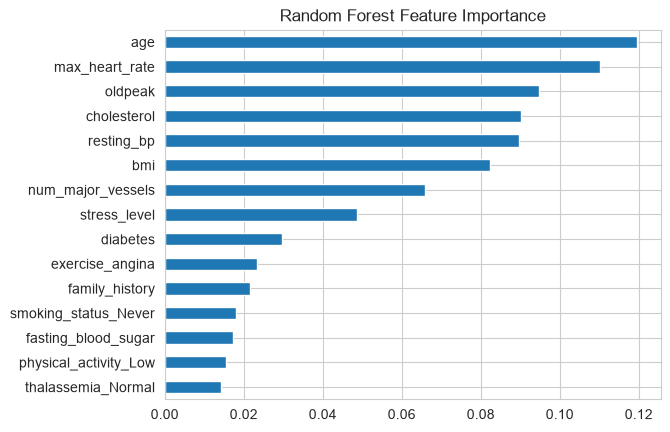

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)
y_proba_rf = rf.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print ("ROC AUC:", roc_auc_score(y_test, y_proba_rf))

importance = pd.Series(rf.feature_importances_, index=x_train.columns).sort_values(ascending=False)
importance.head(15).plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()

COMPARISON TABLE

In [14]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

comparison = pd.DataFrame({
    
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy":[
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf)],
    "Precision":[
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf)],
    "Recall":[
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf)],
    "F1 Score":[
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf)],
    "ROC-AUC":[
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_rf)]
    })
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.780000,0.745133,0.719658,0.732174,0.871117
1,Random Forest,0.760714,0.744141,0.651282,0.694622,0.846519
